## CHB-MIT dataset analysis

In [31]:
import mne
print(mne.__version__)

1.10.1


In [32]:
import os

chb_01 = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\chb01'
print(f"Checking contents of directory: {chb_01}")
try:
    for item in os.listdir(chb_01):
        print(item)
except FileNotFoundError:
    print(f"Error: The directory '{chb_01}' was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An error occurred: {e}")


Checking contents of directory: C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit\chb01
chb01-summary.txt
chb01_01.edf
chb01_02.edf
chb01_03.edf
chb01_03.edf.seizures
chb01_04.edf
chb01_04.edf.seizures
chb01_05.edf
chb01_06.edf
chb01_07.edf
chb01_08.edf
chb01_09.edf
chb01_10.edf
chb01_11.edf
chb01_12.edf
chb01_13.edf
chb01_14.edf
chb01_15.edf
chb01_15.edf.seizures
chb01_16.edf
chb01_16.edf.seizures
chb01_17.edf
chb01_18.edf
chb01_18.edf.seizures
chb01_19.edf
chb01_20.edf
chb01_21.edf
chb01_21.edf.seizures
chb01_22.edf
chb01_23.edf
chb01_24.edf
chb01_25.edf
chb01_26.edf
chb01_26.edf.seizures
chb01_27.edf
chb01_29.edf
chb01_30.edf
chb01_31.edf
chb01_32.edf
chb01_33.edf
chb01_34.edf
chb01_36.edf
chb01_37.edf
chb01_38.edf
chb01_39.edf
chb01_40.edf
chb01_41.edf
chb01_42.edf
chb01_43.edf
chb01_46.edf


In [33]:
import mne

# Updated path to the EDF file based on the latest inspection
patient1file1 = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\chb01\\chb01_01.edf'

try:
    # Load the EDF file
    raw = mne.io.read_raw_edf(patient1file1, preload=True, verbose='warning')
    print(f"Successfully loaded EDF file: {patient1file1}")

    # Inspect the data
    print("\n--- Raw Info ---")
    print(raw.info)

    print("\n--- Channel Names ---")
    print(raw.ch_names[:10]) # Print first 10 channel names
    if len(raw.ch_names) > 10:
        print(f"... and {len(raw.ch_names) - 10} more channels")

    print("\n--- Data Shape (channels, samples) ---")
    print(raw.get_data().shape)

    print("\n--- Sample Frequency ---")
    print(f"{raw.info['sfreq']} Hz")


except Exception as e:
    print(f"An error occurred: {e}")

C:\Users\gorse\AppData\Local\Temp\ipykernel_32964\2068937870.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(patient1file1, preload=True, verbose='warning')


Successfully loaded EDF file: C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit\chb01\chb01_01.edf

--- Raw Info ---
<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 11:42:54 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>

--- Channel Names ---
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4']
... and 13 more channels

--- Data Shape (channels, samples) ---
(23, 921600)

--- Sample Frequency ---
256.0 Hz


C:\Users\gorse\AppData\Local\Temp\ipykernel_32964\2491708657.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(patient1file1, preload=True, verbose='warning')


Successfully loaded EDF file: C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit\chb01\chb01_01.edf
Channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']

--- Plotting Raw Data ---


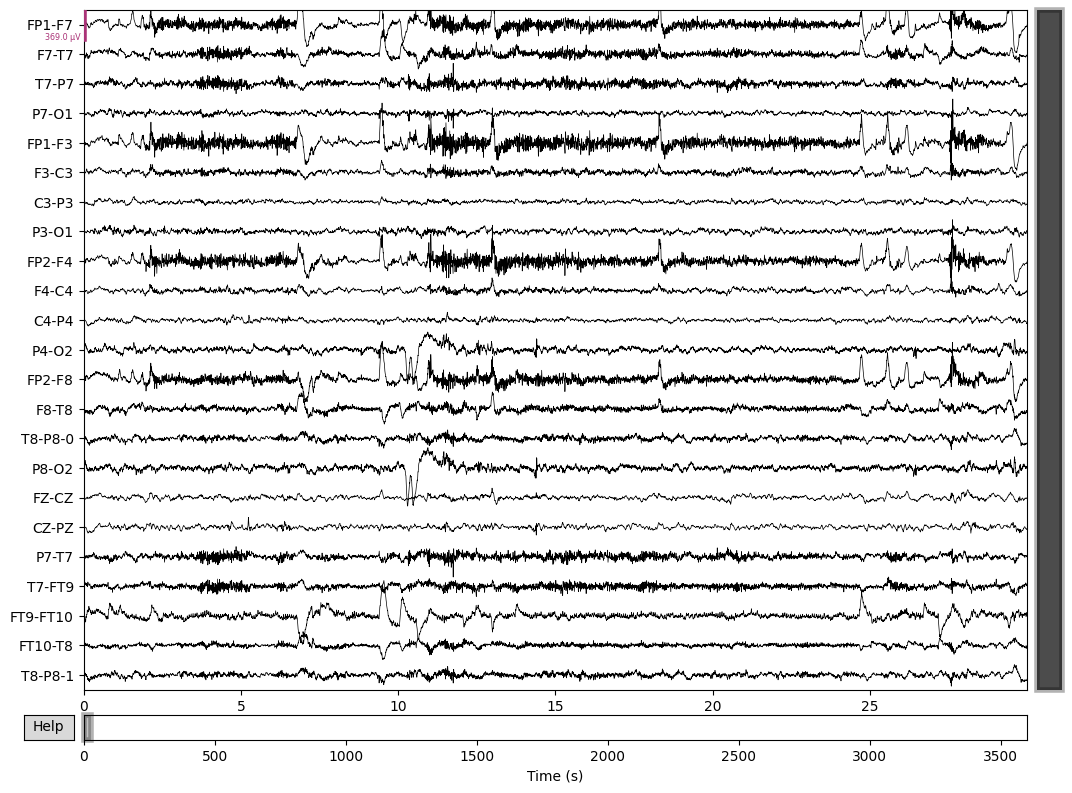

In [34]:
import mne
import numpy as np

# Updated path to the EDF file based on the latest inspection
patient1file1 = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\chb01\\chb01_01.edf'

try:
    # Load the EDF file
    raw = mne.io.read_raw_edf(patient1file1, preload=True, verbose='warning')
    print(f"Successfully loaded EDF file: {patient1file1}")

    # Inspect the data briefly
    print(f"Channels: {raw.ch_names}")

    # --- 1. Set Channel Types Only ---
    # We define these as EEG so MNE knows how to handle the units.
    raw.set_channel_types({name: 'eeg' for name in raw.ch_names}, verbose='warning')

    # --- 2. Calculate Scaling on RAW Data ---
    # We calculate the scaling based on the raw data itself.
    data = raw.get_data()

    # Calculate peak-to-peak amplitude to find a good scale
    # This ensures the messy raw lines don't overlap too much.
    ptp_range = np.ptp(data, axis=1).max()

    # Use 1/10th of the range or 50 microvolts, whichever is larger
    scale_factor = max(50e-6, ptp_range / 10)

    print("\n--- Plotting Raw Data ---")

    # --- 3. Plot with Readable Parameters ---
    raw.plot(
        duration=30.0,                 # Show 30 seconds per window
        n_channels=len(raw.ch_names),  # Show all channels
        scalings={'eeg': scale_factor},# Apply the calculated scaling
        title='CHB-MIT chb01_01 - Raw Unfiltered Data',
        block=True,
    )

except Exception as e:
    print(f"An error occurred: {e}")

In [35]:
print(raw.ch_names)

['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


## 'T8-P8-1' drop 

In [36]:
import os
import re
import mne
import matplotlib.pyplot as plt
import numpy as np

# Path to chb01 folder
chb_01 = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\chb01'
summary_file = os.path.join(chb_01, 'chb01-summary.txt')

# Parse the CHB-MIT Summary File
def parse_summary_text(summary_path):
    """
    Parses the standard chbXX-summary.txt file to extract seizure times.
    Returns a dictionary: { 'filename.edf': [(start, end), (start, end)] }
    """
    seizure_map = {}
    current_file = None

    with open(summary_path, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect Filename
        if line.startswith("File Name:"):
            current_file = line.split("File Name:")[1].strip()
            if current_file not in seizure_map:
                seizure_map[current_file] = []

        # Detect Seizure Times (Standard CHB format)
        if "Seizure" in line and "Start Time" in line:
            try:
                # Extract the start time
                start_sec = int(re.search(r':\s*(\d+)\s*seconds', line).group(1))

                # Look ahead to the next line for End Time
                next_line = lines[i+1].strip()
                end_sec = int(re.search(r':\s*(\d+)\s*seconds', next_line).group(1))

                seizure_map[current_file].append((start_sec, end_sec))
            except (AttributeError, IndexError, ValueError):
                continue

    return seizure_map

Parsing summary file: C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit\chb01\chb01-summary.txt
Processing 42 EDF files...

--- Results for Patient chb01 ---
Total Seizure: 442.00s (0.30%)
Total Non-Seizure: 145545.84s (99.70%)


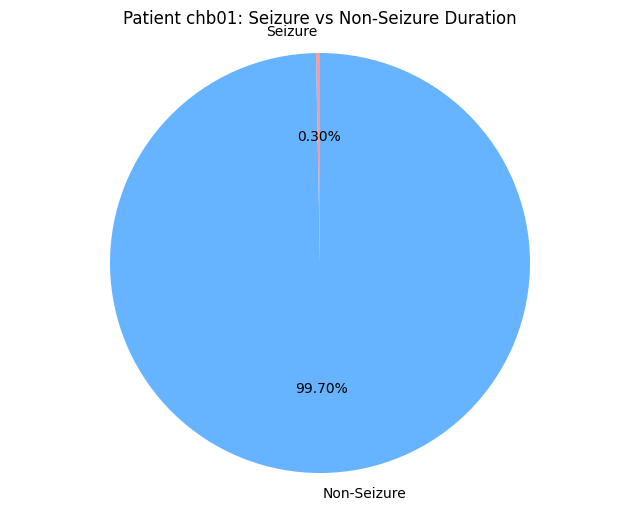

In [37]:
# 1. Parse annotations
print(f"Parsing summary file: {summary_file}")
try:
    file_seizures = parse_summary_text(summary_file)
except FileNotFoundError:
    print("Error: chb01-summary.txt not found. Please check your chb_01 path.")
    file_seizures = {}

total_seizure_duration = 0
total_non_seizure_duration = 0

# Get list of EDF files in directory
edf_files = sorted([f for f in os.listdir(chb_01) if f.endswith('.edf')])

print(f"Processing {len(edf_files)} EDF files...")

for edf_filename in edf_files:
    edf_path = os.path.join(chb_01, edf_filename)

    try:
        raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='error')

        # Get total file duration
        edf_duration = raw.times[-1]

        # Calculate seizure duration for this specific file
        current_seizure_dur = 0
        if edf_filename in file_seizures:
            for start, end in file_seizures[edf_filename]:
                current_seizure_dur += (end - start)

        # Calculate non-seizure
        current_non_seizure_dur = edf_duration - current_seizure_dur

        # Accumulate totals
        total_seizure_duration += current_seizure_dur
        total_non_seizure_duration += current_non_seizure_dur

    except Exception as e:
        print(f"Error processing {edf_filename}: {e}")

# Plotting the Results

total_duration = total_seizure_duration + total_non_seizure_duration
seizure_pct = (total_seizure_duration / total_duration) * 100
non_seizure_pct = (total_non_seizure_duration / total_duration) * 100

print(f"\n--- Results for Patient chb01 ---")
print(f"Total Seizure: {total_seizure_duration:.2f}s ({seizure_pct:.2f}%)")
print(f"Total Non-Seizure: {total_non_seizure_duration:.2f}s ({non_seizure_pct:.2f}%)")

# Create Pie Chart
labels = ['Seizure', 'Non-Seizure']
percentages = [seizure_pct, non_seizure_pct]
colors = ['#ff9999', '#66b3ff'] # Red for seizure, Blue for normal

plt.figure(figsize=(8, 6))
plt.pie(percentages, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
plt.title('Patient chb01: Seizure vs Non-Seizure Duration')
plt.axis('equal')
plt.show()

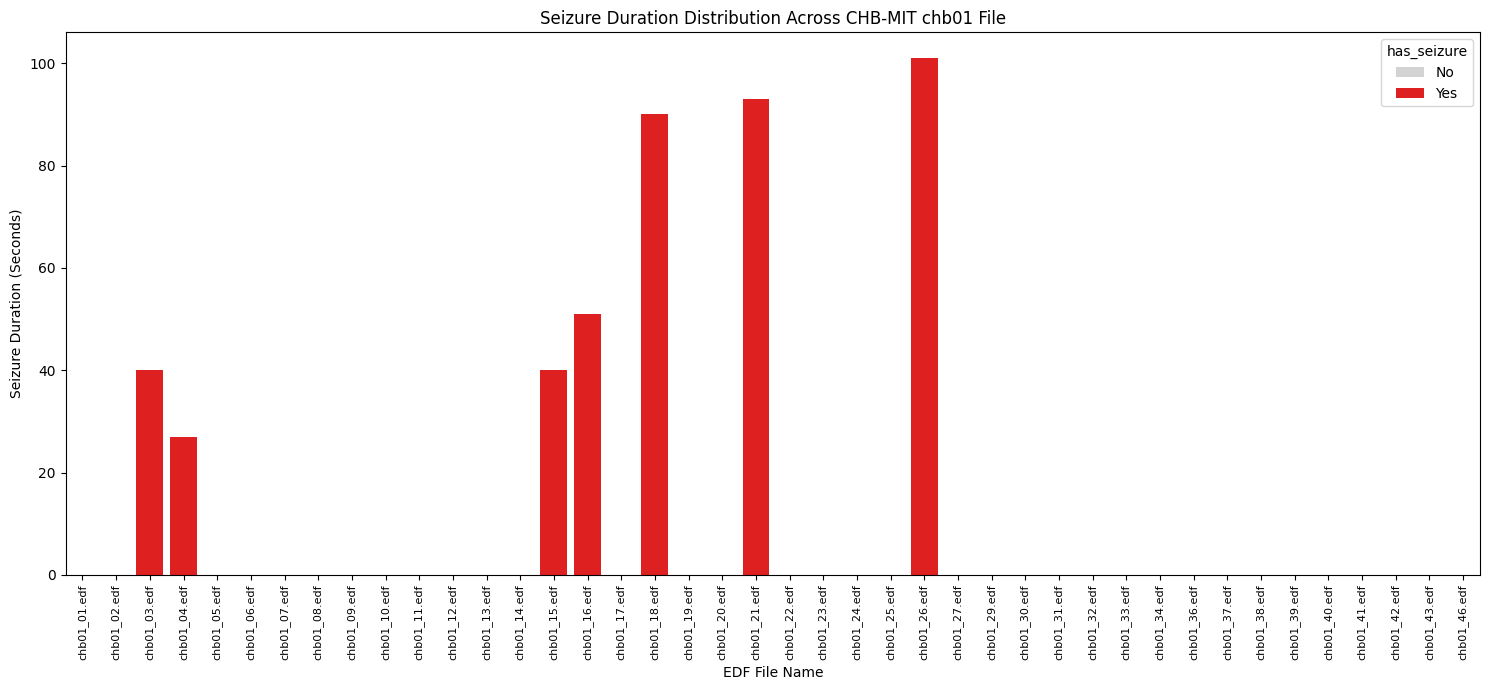

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
seizure_data_per_file = []
for edf_filename, seizure_list in file_seizures.items():
    current_seizure_duration = sum(end - start for start, end in seizure_list)
    seizure_data_per_file.append({
        'filename': edf_filename,
        'seizure_duration_seconds': current_seizure_duration,
        'has_seizure': 'Yes' if current_seizure_duration > 0 else 'No'
    })

df_seizure_distribution = pd.DataFrame(seizure_data_per_file)

# Sort by filename for chronological order
df_seizure_distribution = df_seizure_distribution.sort_values(by='filename').reset_index(drop=True)

plt.figure(figsize=(15, 7))
sns.barplot(
    x='filename',
    y='seizure_duration_seconds',
    hue='has_seizure',
    palette={'Yes': 'red', 'No': 'lightgray'},
    data=df_seizure_distribution,
    dodge=False
)
plt.title('Seizure Duration Distribution Across CHB-MIT chb01 File')
plt.xlabel('EDF File Name')
plt.ylabel('Seizure Duration (Seconds)')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

C:\Users\gorse\AppData\Local\Temp\ipykernel_32964\3967510358.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\gorse\AppData\Local\Temp\ipykernel_32964\3967510358.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


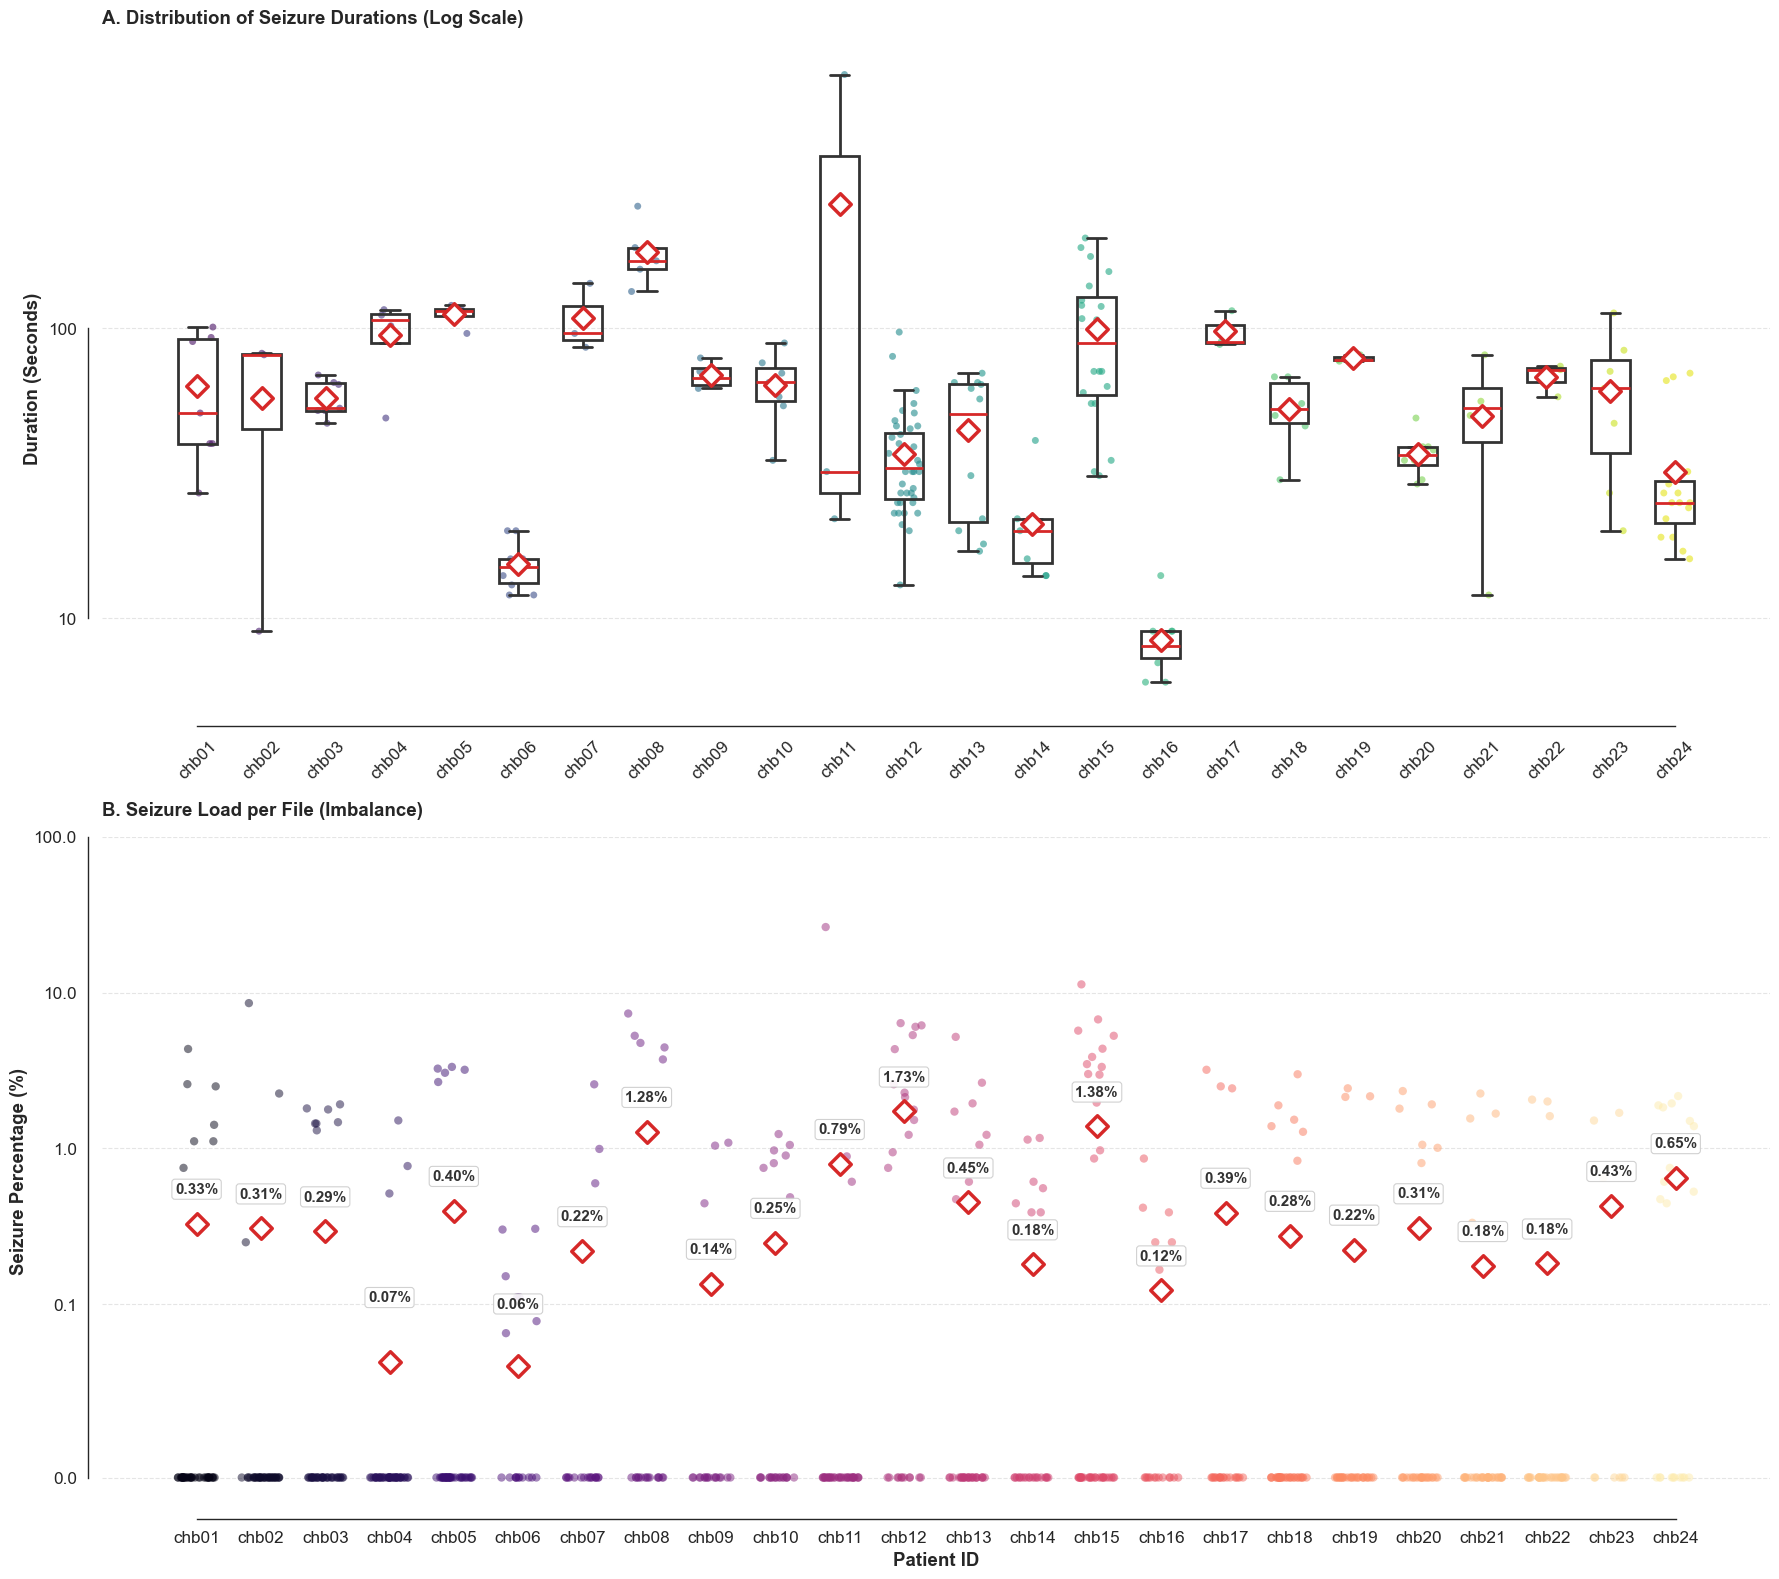

In [78]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import mne 
from matplotlib.ticker import ScalarFormatter

# ---------------------------------------------------------
# 1. SETUP AND DATA LOADING (Keep your existing loading code)
# ---------------------------------------------------------
# ... (Paste your existing PART 1 code here) ...
# Ensure you have 'data_durations' and 'data_percentages' populated
# ---------------------------------------------------------

# ---------------------------------------------------------
# 2. VISUALIZATION LOGIC
# ---------------------------------------------------------
if data_percentages and data_durations:
    
    # Create DataFrames
    df_seizures = pd.DataFrame(data_durations)
    df_files = pd.DataFrame(data_percentages)
    patient_order = sorted(df_files['Patient ID'].unique())
    
    # Set a clean, professional theme
    sns.set_theme(style="white", context="paper", font_scale=1.4)
    
    # Initialize Figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 16)) # No sharex, we want control over each layout

    # =======================================================
    # PLOT A: SEIZURE DURATIONS (Transparent Box + Color Strip)
    # =======================================================
    
    # 1. The Strip Plot (Raw Data) - Plot this FIRST so it's at the back, or LAST for front?
    # We plot it first, then the box outline on top.
    sns.stripplot(
        data=df_seizures,
        x='Patient ID',
        y='Seizure Duration (s)',
        ax=ax1,
        order=patient_order,
        palette='viridis',     # The dots carry the color
        size=5,
        alpha=0.6,             # Transparency helps see density
        jitter=0.25,
        zorder=1
    )

    # 2. The Box Plot (Statistical Outline) - Transparent
    sns.boxplot(
        data=df_seizures,
        x='Patient ID',
        y='Seizure Duration (s)',
        ax=ax1,
        order=patient_order,
        showfliers=False,      # Hide outliers (dots already show them)
        width=0.6,
        linewidth=2,
        boxprops=dict(facecolor="none", edgecolor="#333333", zorder=2), # See-through boxes
        whiskerprops=dict(color="#333333", linewidth=2),
        capprops=dict(color="#333333", linewidth=2),
        medianprops=dict(color="#D62828", linewidth=2) # Red median line
    )
    
    # 3. Add Mean Markers (Red Diamonds)
    seizure_means = df_seizures.groupby('Patient ID')['Seizure Duration (s)'].mean().reindex(patient_order)
    ax1.scatter(
        range(len(patient_order)), seizure_means,
        color='white', s=120, marker='D', zorder=3, edgecolors='#D62828', linewidth=2.5, label='Mean'
    )

    # 4. Clean Log Scale for Duration (Handles the massive range 10s -> 1000s)
    ax1.set_yscale('log')
    ax1.yaxis.set_major_formatter(ScalarFormatter()) # 10, 100, 1000 instead of 10^1, 10^2
    
    # 5. Styling
    ax1.set_title('A. Distribution of Seizure Durations (Log Scale)', loc='left', fontweight='bold', pad=15)
    ax1.set_ylabel('Duration (Seconds)', fontweight='bold')
    ax1.set_xlabel('')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.tick_params(axis='x', rotation=45)

    # =======================================================
    # PLOT B: SEIZURE PERCENTAGE (Strip Plot Only)
    # =======================================================
    # Boxplots are removed because they mislead on zero-heavy data.
    
    # 1. The Strip Plot
    sns.stripplot(
        data=df_files,
        x='Patient ID',
        y='Seizure Percentage',
        ax=ax2,
        order=patient_order,
        palette='magma',       # Different palette to distinguish from top plot
        size=6,
        alpha=0.5,
        jitter=0.3,
        zorder=1
    )

    # 2. Add Mean Markers
    pct_means = df_files.groupby('Patient ID')['Seizure Percentage'].mean().reindex(patient_order)
    
    # Plot the mean
    ax2.scatter(
        range(len(patient_order)), pct_means,
        color='white', s=120, marker='D', zorder=3, edgecolors='#D62828', linewidth=2.5, label='Mean %'
    )
    
    # 3. Add Text Labels for Means (Only on bottom plot where it's critical)
    # We stagger them to avoid overlap if needed, or just float them above.
    for x, val in enumerate(pct_means):
        if pd.notna(val):
            ax2.text(
                x, val * 1.5 if val > 0 else 0.1, # Float slightly above
                f"{val:.2f}%", 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='#333',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='#ccc', boxstyle='round,pad=0.2')
            )

    # 4. SymLog Scale (Crucial for visualizing 0 vs 10%)
    ax2.set_yscale('symlog', linthresh=0.1) 
    # linthresh=0.1 means values between 0 and 0.1 are linear, above 0.1 is log.
    # This separates the "0" cluster from the "0.5%" and "25%" points clearly.
    
    # Manual Y-ticks to make the log scale readable
    ax2.set_yticks([0, 0.1, 1, 10, 100])
    ax2.get_yaxis().set_major_formatter(ScalarFormatter())

    # 5. Styling
    ax2.set_title('B. Seizure Load per File (Imbalance)', loc='left', fontweight='bold', pad=15)
    ax2.set_ylabel('Seizure Percentage (%)', fontweight='bold')
    ax2.set_xlabel('Patient ID', fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Rotate X labels nicely
    plt.sca(ax2)
    plt.xticks(rotation=45, ha='right')
    
    # Final Polish
    sns.despine(offset=10, trim=True) # Removes the box border, leaves axes
    plt.tight_layout()
    plt.show()


C:\Users\gorse\AppData\Local\Temp\ipykernel_32964\3406716682.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\gorse\AppData\Local\Temp\ipykernel_32964\3406716682.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


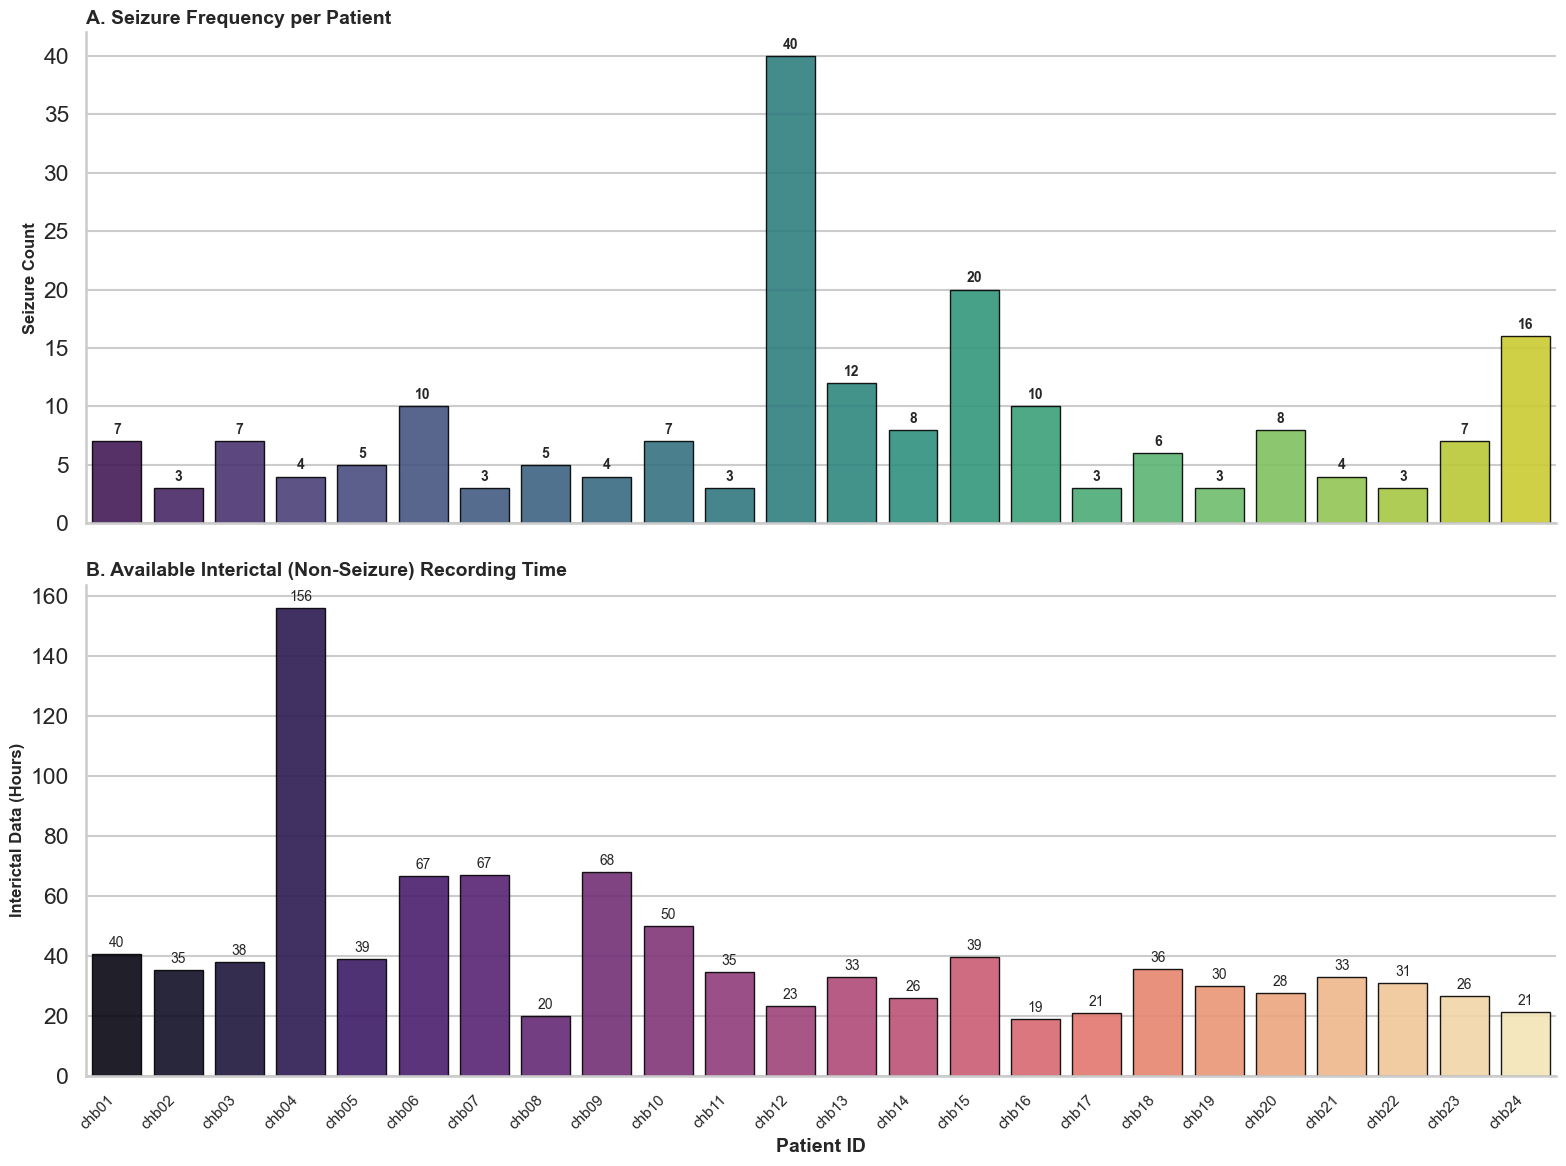

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import mne

# ... (Include your PART 1: DATA LOADING code here exactly as you have it) ...
# ... ensuring 'patient_characteristics' dictionary is populated ...

# ---------------------------------------------------------
# 2. IMPROVED VISUALIZATION
# ---------------------------------------------------------

if patient_characteristics:
    # 1. Convert to DataFrame for easier handling
    df = pd.DataFrame.from_dict(patient_characteristics, orient='index')
    df.index.name = 'PatientID'
    df.reset_index(inplace=True)
    
    # OPTIONAL: Sort by Number of Seizures to reveal patterns
    # df = df.sort_values(by='num_seizures', ascending=False)

    # 2. Setup Figure with 2 vertical subplots sharing the X-axis
    sns.set_theme(style="whitegrid", context="talk")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    
    # -----------------------------------------------------
    # TOP PLOT: Number of Seizures (The "Event" Count)
    # -----------------------------------------------------
    sns.barplot(
        data=df, 
        x='PatientID', 
        y='num_seizures', 
        ax=ax1, 
        palette='viridis',     # Scientific, colorblind-friendly
        edgecolor='black',
        linewidth=1,
        alpha=0.9
    )
    
    # Add value labels on top of bars
    for container in ax1.containers:
        ax1.bar_label(container, padding=3, fontsize=10, fontweight='bold')

    ax1.set_ylabel('Seizure Count', fontweight='bold', fontsize=12)
    ax1.set_title('A. Seizure Frequency per Patient', loc='left', fontweight='bold', fontsize=14)
    ax1.grid(axis='x', alpha=0) # Clean up vertical grids
    
    # -----------------------------------------------------
    # BOTTOM PLOT: Interictal Hours (The "Background" Data)
    # -----------------------------------------------------
    sns.barplot(
        data=df, 
        x='PatientID', 
        y='interictal_hours', 
        ax=ax2, 
        palette='magma',       # Distinct palette to differentiate from top plot
        edgecolor='black',
        linewidth=1,
        alpha=0.9
    )
    
    # Add value labels
    for container in ax2.containers:
        ax2.bar_label(container, fmt='%.0f', padding=3, fontsize=10)

    ax2.set_ylabel('Interictal Data (Hours)', fontweight='bold', fontsize=12)
    ax2.set_title('B. Available Interictal (Non-Seizure) Recording Time', loc='left', fontweight='bold', fontsize=14)
    ax2.set_xlabel('Patient ID', fontweight='bold', fontsize=14)
    ax2.grid(axis='x', alpha=0)

    # Rotate x-labels for better reading
    plt.xticks(rotation=45, ha='right', fontsize=11)
    
    # Remove top/right spines for a cleaner look
    sns.despine()

    plt.tight_layout()
    plt.show()

else:
    print("No patient data found to plot.")

Found 24 patients: ['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10', 'chb11', 'chb12', 'chb13', 'chb14', 'chb15', 'chb16', 'chb17', 'chb18', 'chb19', 'chb20', 'chb21', 'chb22', 'chb23', 'chb24']

Processing chb01...
  Seizures: 7, Interictal hours: 40.43
Processing chb02...
  Seizures: 3, Interictal hours: 35.22
Processing chb03...
  Seizures: 7, Interictal hours: 37.89
Processing chb04...
  Seizures: 4, Interictal hours: 155.96
Processing chb05...
  Seizures: 5, Interictal hours: 38.85
Processing chb06...
  Seizures: 10, Interictal hours: 66.69
Processing chb07...
  Seizures: 3, Interictal hours: 66.96
Processing chb08...
  Seizures: 5, Interictal hours: 19.75
Processing chb09...
  Seizures: 4, Interictal hours: 67.79
Processing chb10...
  Seizures: 7, Interictal hours: 49.90
Processing chb11...
  Seizures: 3, Interictal hours: 34.57
Processing chb12...
  Seizures: 40, Interictal hours: 23.28
Processing chb13...
  Seizures: 12, Interictal hours

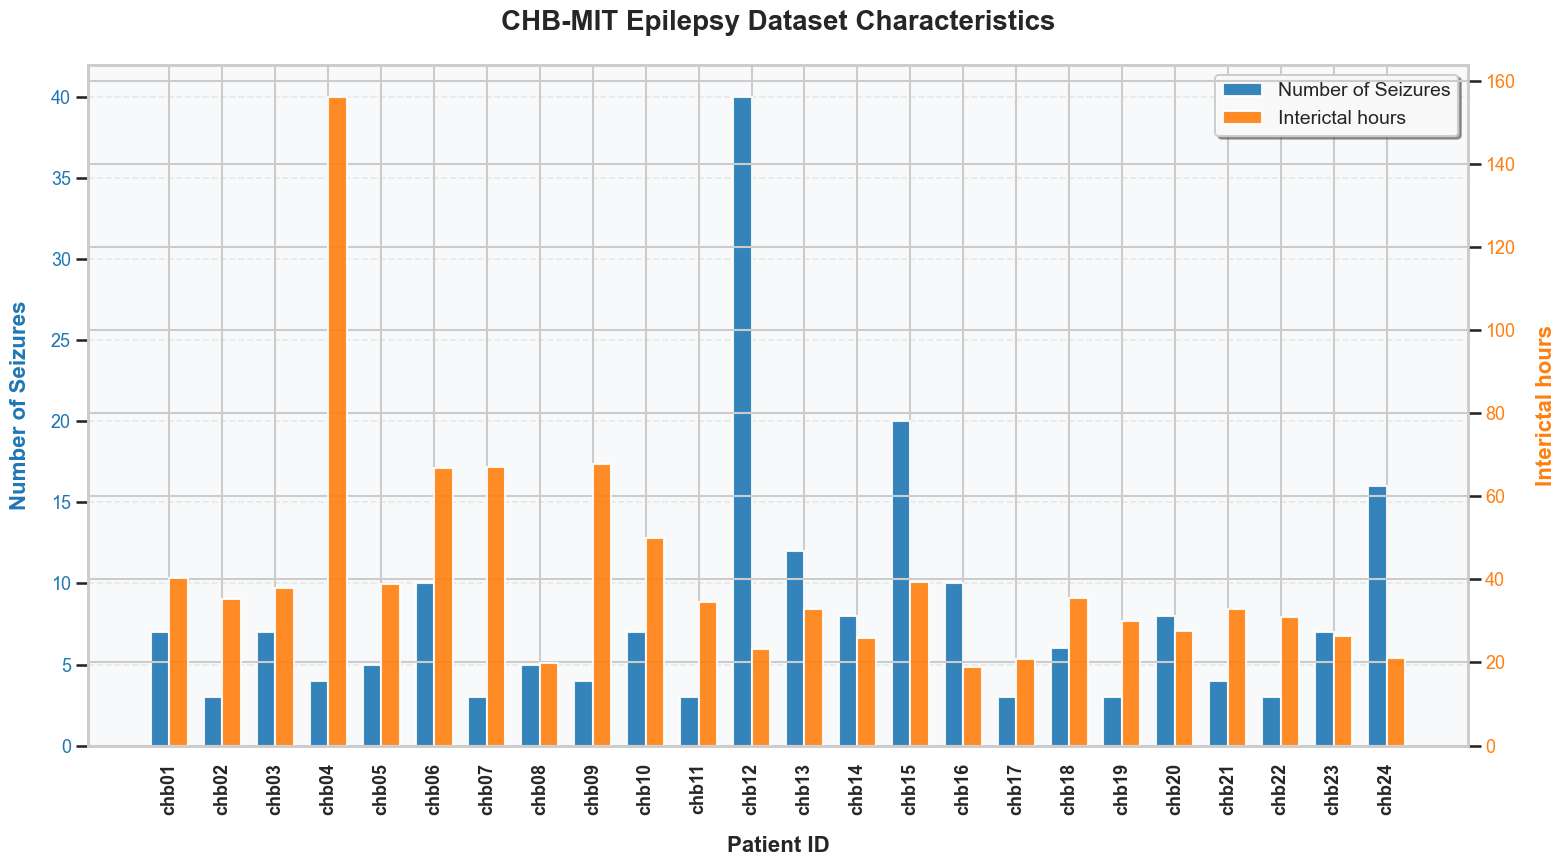

In [76]:
base_dir = 'C:\\Users\\gorse\\OneDrive - TUNI.fi\\Desktop\\Tez\\uvtez\\data\\chb-mit\\'

# Get all patient directories
patient_dirs = sorted([d for d in os.listdir(base_dir)
                      if os.path.isdir(os.path.join(base_dir, d)) and d.startswith('chb')])

print(f"Found {len(patient_dirs)} patients: {patient_dirs}\n")

# Store characteristics for each patient
patient_characteristics = {}

for patient_id in patient_dirs:
    patient_dir = os.path.join(base_dir, patient_id)
    summary_file = os.path.join(patient_dir, f"{patient_id}-summary.txt")

    print(f"Processing {patient_id}...")

    # Parse annotations
    try:
        file_seizures = parse_summary_text(summary_file)
    except FileNotFoundError:
        print(f"  Warning: Summary file not found for {patient_id}, skipping.")
        continue
    except Exception as e:
        print(f"  Error parsing summary for {patient_id}: {e}")
        continue

    # Count number of seizures
    num_seizures = sum(len(seizures) for seizures in file_seizures.values())

    # Calculate total interictal hours (non-seizure time)
    total_duration = 0
    total_seizure_duration = 0

    edf_files = sorted([f for f in os.listdir(patient_dir) if f.endswith('.edf')])

    for edf_filename in edf_files:
        edf_path = os.path.join(patient_dir, edf_filename)

        try:
            raw = mne.io.read_raw_edf(edf_path, preload=False, verbose='error')
            file_duration = raw.times[-1]
            total_duration += file_duration

            # Calculate seizure duration for this file
            if edf_filename in file_seizures:
                for start, end in file_seizures[edf_filename]:
                    total_seizure_duration += (end - start)

        except Exception as e:
            print(f"  Error processing {edf_filename}: {e}")

    # Calculate interictal time (non-seizure) in hours
    interictal_duration = total_duration - total_seizure_duration
    interictal_hours = interictal_duration / 3600  # Convert seconds to hours

    patient_characteristics[patient_id] = {
        'num_seizures': num_seizures,
        'interictal_hours': interictal_hours
    }

    print(f"  Seizures: {num_seizures}, Interictal hours: {interictal_hours:.2f}")

print(f"\n{'='*60}")
print(f"Successfully processed {len(patient_characteristics)} patients\n")

# Create the dual-axis bar chart (similar to the reference figure)
if patient_characteristics:
    patients = list(patient_characteristics.keys())
    num_seizures = [patient_characteristics[p]['num_seizures'] for p in patients]
    interictal_hours = [patient_characteristics[p]['interictal_hours'] for p in patients]

    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=(16, 9))

    # Set up x-axis positions
    x = np.arange(len(patients))
    width = 0.35

    # Plot number of seizures on primary y-axis (left)
    bars1 = ax1.bar(x - width/2, num_seizures, width,
                    label='Number of Seizures', color='#1f77b4',
                    alpha=0.9, edgecolor='white', linewidth=1.5)

    ax1.set_xlabel('Patient ID', fontsize=16, fontweight='bold', labelpad=15)
    ax1.set_ylabel('Number of Seizures', fontsize=16, fontweight='bold',
                   labelpad=15, color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4', labelsize=13)
    ax1.set_xticks(x)
    ax1.set_xticklabels(patients, rotation=90, fontsize=13, fontweight='semibold')

    # Create secondary y-axis for interictal hours (right)
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, interictal_hours, width,
                    label='Interictal hours', color='#ff7f0e',
                    alpha=0.9, edgecolor='white', linewidth=1.5)

    ax2.set_ylabel('Interictal hours', fontsize=16, fontweight='bold',
                   labelpad=15, color='#ff7f0e')
    ax2.tick_params(axis='y', labelcolor='#ff7f0e', labelsize=13)

    # Add title
    ax1.set_title('CHB-MIT Epilepsy Dataset Characteristics',
                  fontsize=20, fontweight='bold', pad=25)

    # Add grid on primary axis
    ax1.grid(axis='y', alpha=0.4, linestyle='--', linewidth=1.2)
    ax1.set_axisbelow(True)

    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
              loc='upper right', fontsize=14, frameon=True,
              shadow=True, fancybox=True, framealpha=0.95)

    # Set background color
    ax1.set_facecolor('#F8F9FA')
    fig.patch.set_facecolor('white')

    plt.tight_layout()
    plt.show()

C:\Users\gorse\AppData\Local\Temp\ipykernel_32964\3406716682.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\gorse\AppData\Local\Temp\ipykernel_32964\3406716682.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


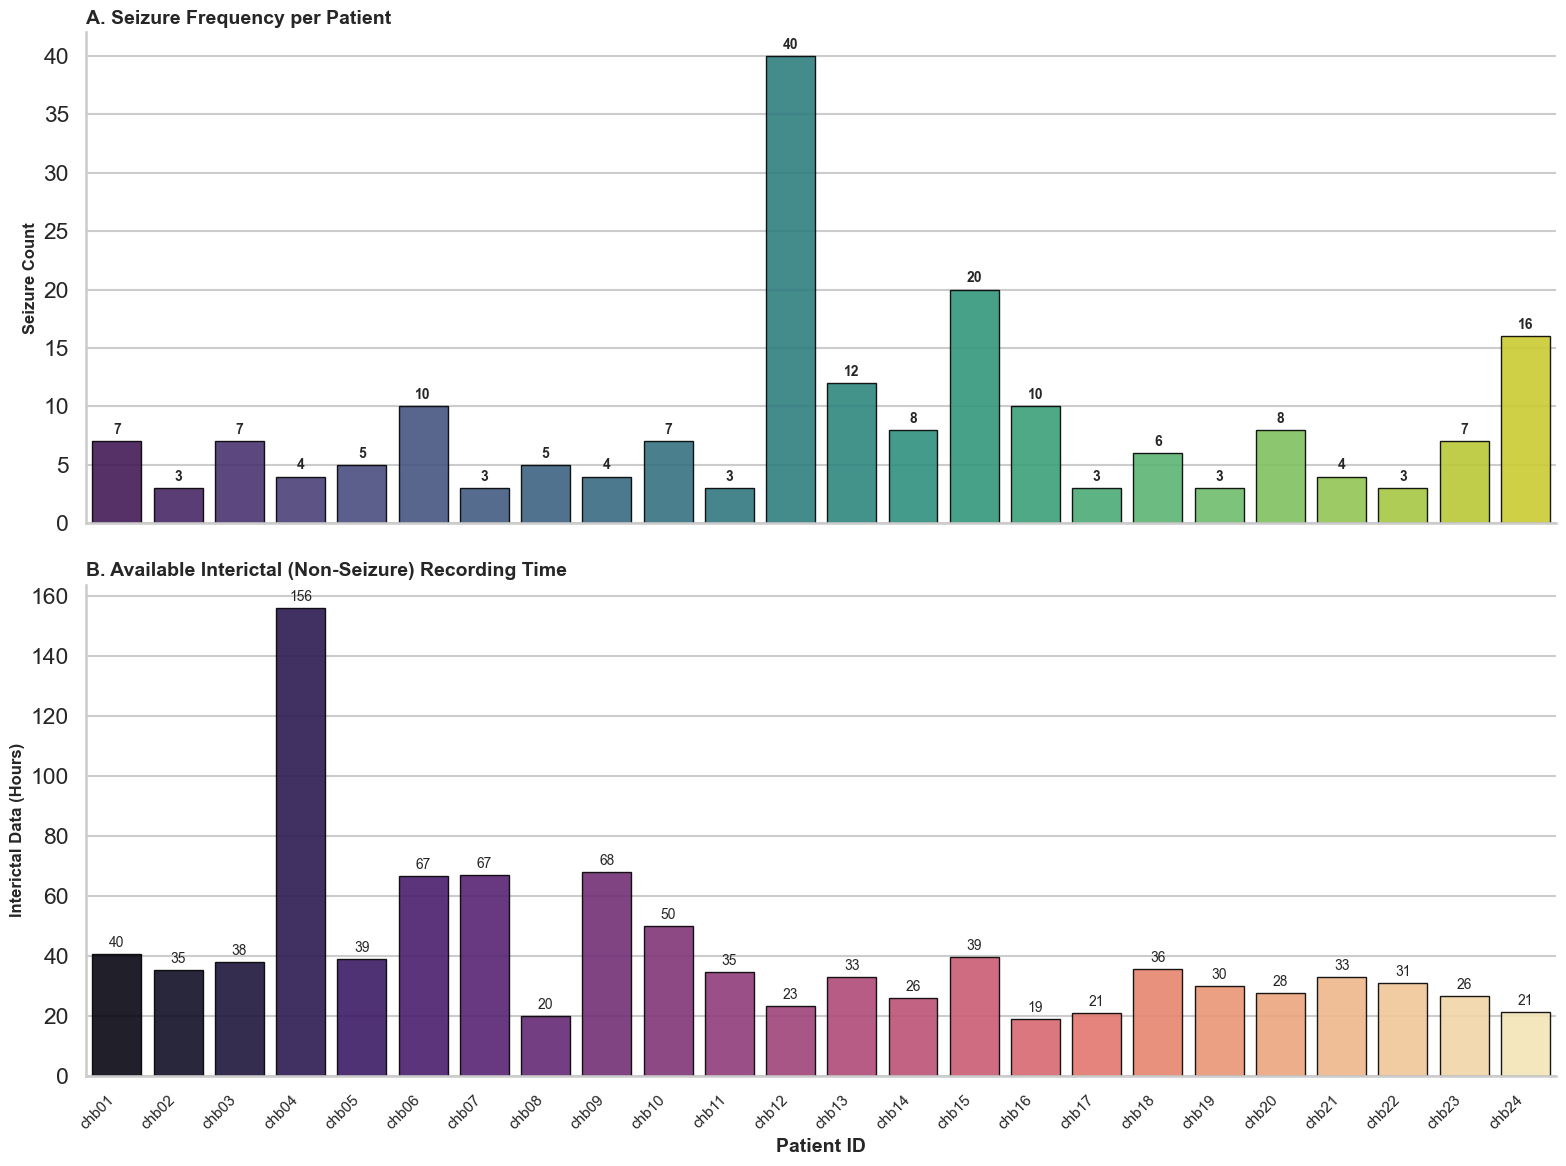

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import mne

# ... (Include your PART 1: DATA LOADING code here exactly as you have it) ...
# ... ensuring 'patient_characteristics' dictionary is populated ...

# ---------------------------------------------------------
# 2. IMPROVED VISUALIZATION
# ---------------------------------------------------------

if patient_characteristics:
    # 1. Convert to DataFrame for easier handling
    df = pd.DataFrame.from_dict(patient_characteristics, orient='index')
    df.index.name = 'PatientID'
    df.reset_index(inplace=True)
    
    # OPTIONAL: Sort by Number of Seizures to reveal patterns
    # df = df.sort_values(by='num_seizures', ascending=False)

    # 2. Setup Figure with 2 vertical subplots sharing the X-axis
    sns.set_theme(style="whitegrid", context="talk")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    
    # -----------------------------------------------------
    # TOP PLOT: Number of Seizures (The "Event" Count)
    # -----------------------------------------------------
    sns.barplot(
        data=df, 
        x='PatientID', 
        y='num_seizures', 
        ax=ax1, 
        palette='viridis',     # Scientific, colorblind-friendly
        edgecolor='black',
        linewidth=1,
        alpha=0.9
    )
    
    # Add value labels on top of bars
    for container in ax1.containers:
        ax1.bar_label(container, padding=3, fontsize=10, fontweight='bold')

    ax1.set_ylabel('Seizure Count', fontweight='bold', fontsize=12)
    ax1.set_title('A. Seizure Frequency per Patient', loc='left', fontweight='bold', fontsize=14)
    ax1.grid(axis='x', alpha=0) # Clean up vertical grids
    
    # -----------------------------------------------------
    # BOTTOM PLOT: Interictal Hours (The "Background" Data)
    # -----------------------------------------------------
    sns.barplot(
        data=df, 
        x='PatientID', 
        y='interictal_hours', 
        ax=ax2, 
        palette='magma',       # Distinct palette to differentiate from top plot
        edgecolor='black',
        linewidth=1,
        alpha=0.9
    )
    
    # Add value labels
    for container in ax2.containers:
        ax2.bar_label(container, fmt='%.0f', padding=3, fontsize=10)

    ax2.set_ylabel('Interictal Data (Hours)', fontweight='bold', fontsize=12)
    ax2.set_title('B. Available Interictal (Non-Seizure) Recording Time', loc='left', fontweight='bold', fontsize=14)
    ax2.set_xlabel('Patient ID', fontweight='bold', fontsize=14)
    ax2.grid(axis='x', alpha=0)

    # Rotate x-labels for better reading
    plt.xticks(rotation=45, ha='right', fontsize=11)
    
    # Remove top/right spines for a cleaner look
    sns.despine()

    plt.tight_layout()
    plt.show()

else:
    print("No patient data found to plot.")

## Plotting spectral density of continuous data

---

c:\Users\gorse\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


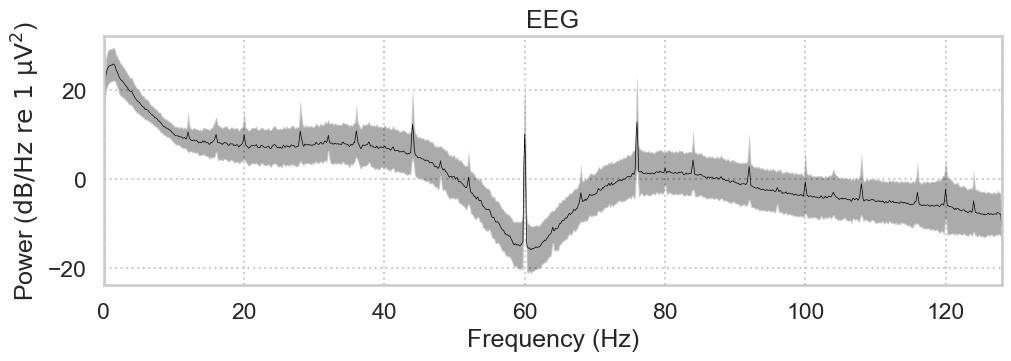

In [43]:
# Use the loaded Raw object `raw` (not the path string `chb_01`) to compute / plot PSD.
raw.plot_psd(average=True, picks='eeg', exclude='bads')

c:\Users\gorse\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
c:\Users\gorse\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


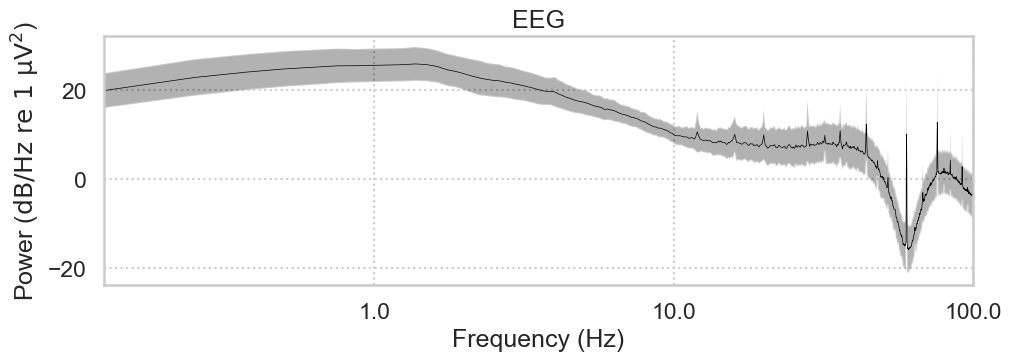

In [44]:
# 1. Compute PSD up to a relevant max frequency (100Hz to see the drop-off)
spectrum = raw.compute_psd(fmax=100)

# 2. Plot without averaging first to see if specific channels are noisy
spectrum.plot(average=False, picks="data", exclude="bads", amplitude=False, spatial_colors=True)

# 3. Plot with a log scale on X if you need to inspect low-freq drift closely
spectrum.plot(average=True, xscale="log")

#### Channel Quality

In [45]:
ch_labels = raw.ch_names
# Pick only the desired channels
raw.pick_channels(ch_labels)

print(raw.ch_names)

['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


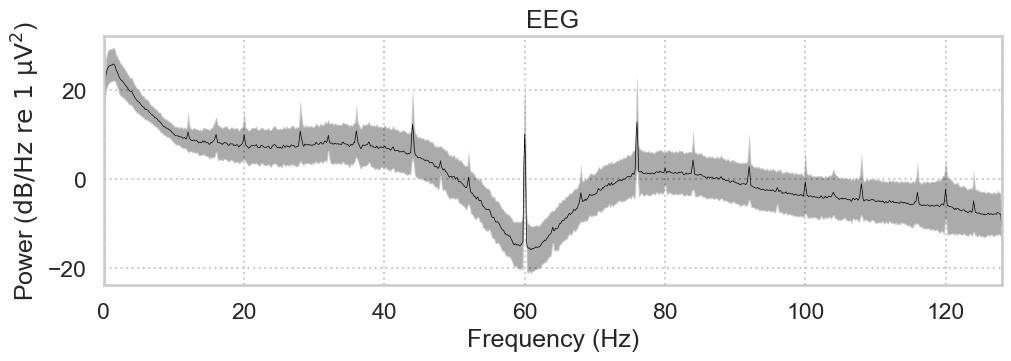

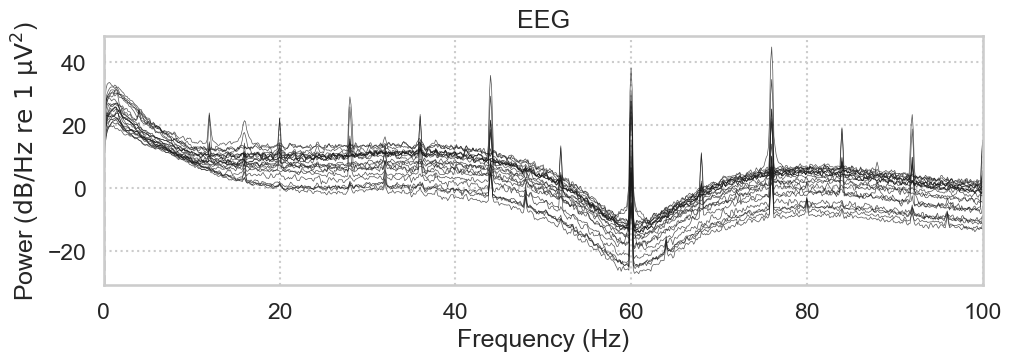

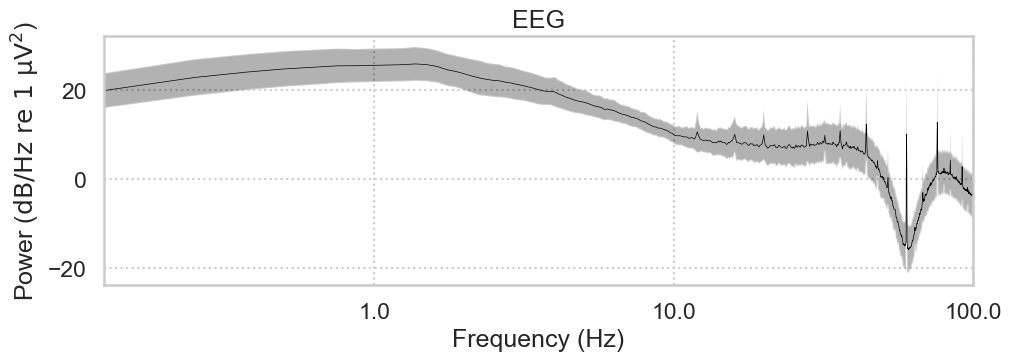

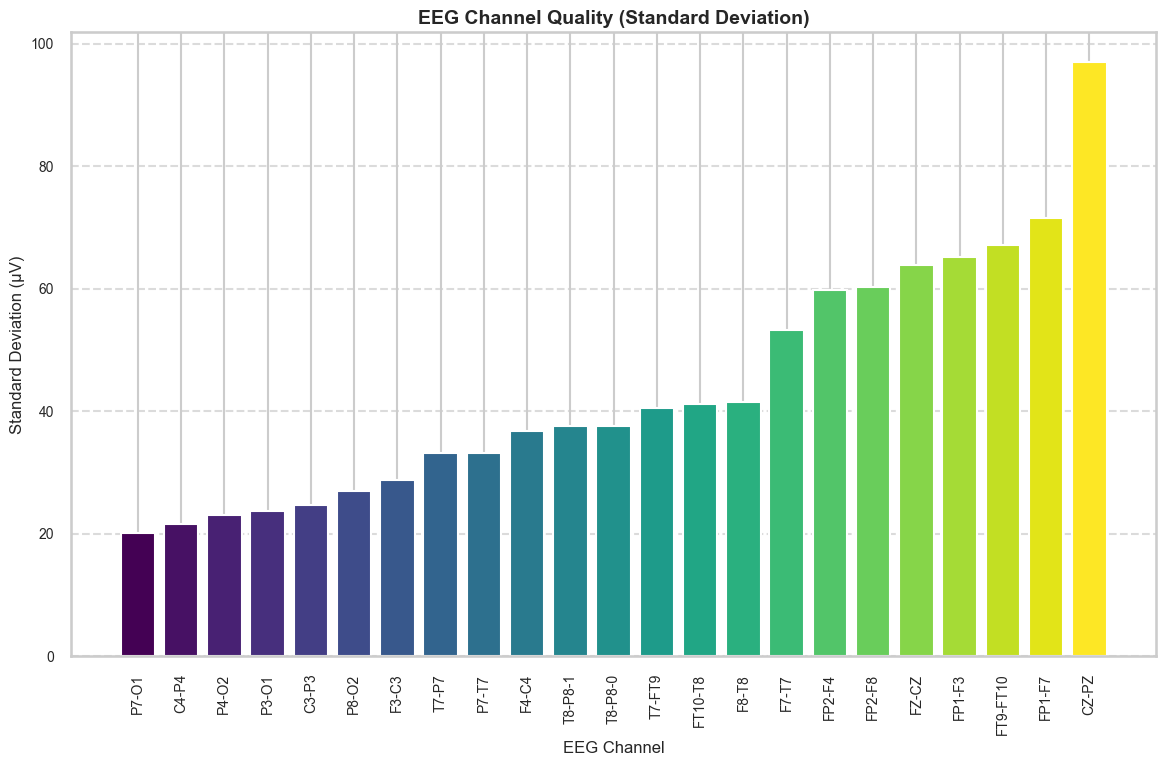

In [46]:
# Ensure only EEG channels are selected
eeg_channels = raw.pick_types(eeg=True, meg=False, stim=False, exclude='bads')

channel_stds = np.std(eeg_channels.get_data(), axis=1)

# Sort channels by their standard deviation for better visualization
sorted_indices = np.argsort(channel_stds)
sorted_channel_stds = channel_stds[sorted_indices]
sorted_channel_names = [eeg_channels.ch_names[i] for i in sorted_indices]

# Create a colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_channel_names)))

plt.figure(figsize=(12, 8))
plt.bar(sorted_channel_names, sorted_channel_stds * 1e6, color=colors)
plt.xlabel('EEG Channel', fontsize=12)
plt.ylabel('Standard Deviation (µV)', fontsize=12)
plt.title('EEG Channel Quality (Standard Deviation)', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Auditing for Preprocessing

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from pathlib import Path


In [48]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [49]:
import sys
import os
from pathlib import Path

# 1. Get the current working directory
current_dir = Path(os.getcwd())

# 2. Find the Project Root
if current_dir.name == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = Path(r"C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez")

# 3. CRITICAL CHANGE: Point specifically to the 'src' folder
src_path = project_root / "src"

# 4. Insert 'src' into sys.path
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"✅ Added 'src' to Path: {src_path}")

# 5. Verification Check
# Notice: We removed 'src.' from the import below
try:
    from eeg.preprocessing import CHBMITPreprocessor
    print("✅ SUCCESS: 'eeg.preprocessing' found and imported!")
except ModuleNotFoundError as e:
    print(f"❌ FAIL: {e}")

✅ Added 'src' to Path: c:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\src
✅ SUCCESS: 'eeg.preprocessing' found and imported!


In [50]:
from eeg.preprocessing import CHBMITPreprocessor
from pathlib import Path
import mne

# # 1. Define paths as variables first (Use Path objects for easier handling)
raw_data_dir = Path(r"C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\chb-mit")
processed_dir = Path(r"C:\Users\gorse\OneDrive - TUNI.fi\Desktop\Tez\uvtez\data\preprocessed")

# 2. Initialize the Preprocessor using those variables
preprocessor = CHBMITPreprocessor(
    base_dir=raw_data_dir,
    output_dir=processed_dir
 )

# 3. Find the raw file correctly
# We look inside 'raw_data_dir' (and likely the subject subfolder like 'chb01')
subject_id = "chb01"  # Define which subject you are testing
subject_folder = raw_data_dir / subject_id

# Check if the folder exists to avoid errors
if not subject_folder.exists():
    print(f"❌ Error: Could not find folder: {subject_folder}")
else:
    edf_files = sorted(subject_folder.glob("*.edf"))
    
    if edf_files:
        edf_path = edf_files[0]
        print(f"Found file: {edf_path.name}")
        
       # Load the raw data
        raw_before = mne.io.read_raw_edf(
            edf_path,
            preload=True,
            verbose="error"
        )
        print("✅ Raw data loaded successfully!")
    else:
     print(f"❌ No .edf files found in {subject_folder}")

Found file: chb01_01.edf
✅ Raw data loaded successfully!


In [51]:
print(raw_before)
print(len(raw_before.ch_names))
print(raw_before.info["sfreq"])

<RawEDF | chb01_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>
23
256.0


In [52]:
def plot_psd(raw, title, fmax=70):
    psd = raw.compute_psd(fmax=fmax, verbose="error")
    psd.plot(
        average=True,
        spatial_colors=False,
        show=False
    )
    plt.title(title)
    plt.show()


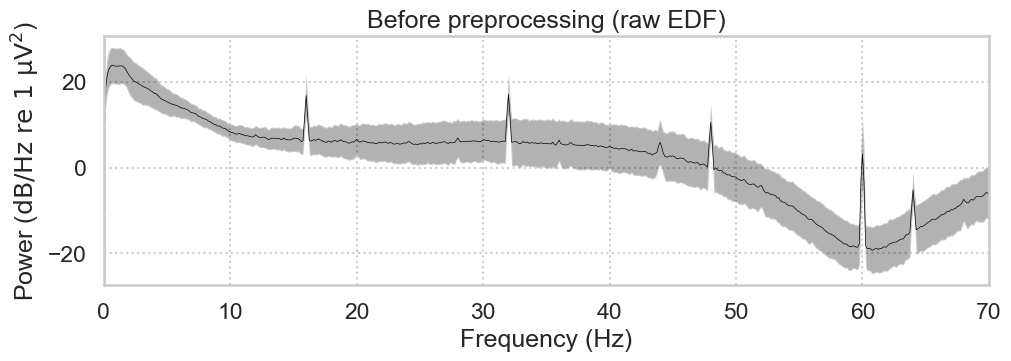

In [53]:
plot_psd(raw_before, "Before preprocessing (raw EDF)")

In [54]:
# 1. Create a copy so we don't overwrite raw_before
raw_after = raw_before.copy()

# 2. Detect and drop bad channels (using your class logic)
# The class method 'detect_bad_channels' returns a list of bad channel names
bad_channels_list = preprocessor.detect_bad_channels(raw_after)
print(f"Detected bad channels: {bad_channels_list}")
raw_after.drop_channels(bad_channels_list)

# 3. Apply Filtering (Bandpass 0.5–60 Hz + Notch 60 Hz)
# The class method 'apply_filtering' returns the filtered Raw object
raw_after = preprocessor.apply_filtering(raw_after)

# 4. Downsample (256 Hz -> 128 Hz)
raw_after = preprocessor.downsample(raw_after)

Detected bad channels: []


In [55]:
def plot_psd(raw_after, title, fmax=60):
    psd = raw_after.compute_psd(fmax=fmax, verbose="error")
    psd.plot(
        average=True,
        spatial_colors=False,
        show=False
    )
    plt.title(title)
    plt.show()


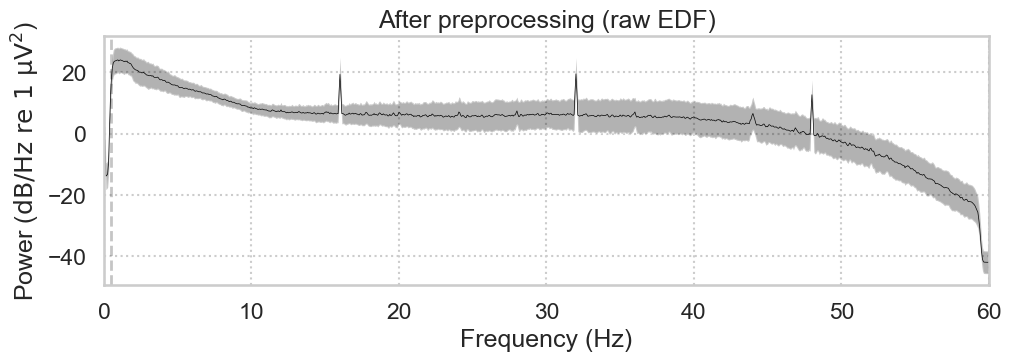

In [56]:
plot_psd(raw_after, "After preprocessing (raw EDF)")

Total Raw Channels:       23
Total Processed Channels: 23
❌ Dropped Channels (0): []


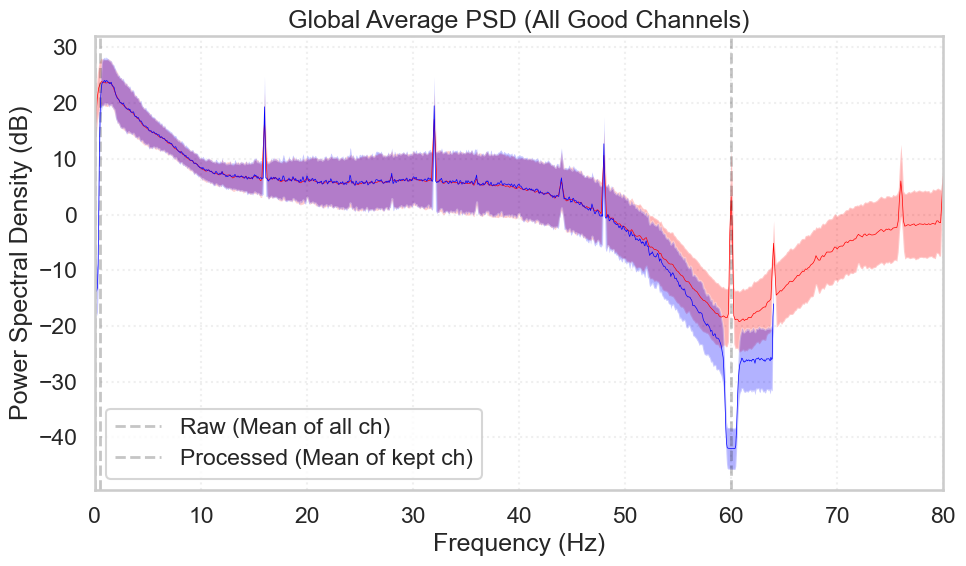

In [57]:
import matplotlib.pyplot as plt
import mne
import numpy as np

# --- 1. Settings ---
mne.set_log_level("ERROR") 

# --- 2. Identify Dropped Channels ---
ch_raw = set(raw_before.ch_names)
ch_proc = set(raw_after.ch_names)

# The difference between the sets are the dropped channels
dropped_channels = list(ch_raw - ch_proc)
kept_channels = list(ch_proc)

print("="*40)
print(f"Total Raw Channels:       {len(ch_raw)}")
print(f"Total Processed Channels: {len(ch_proc)}")
print(f"❌ Dropped Channels ({len(dropped_channels)}): {dropped_channels}")
print("="*40)

# --- 3. Visualization (Global Average) ---
fig, ax = plt.subplots(figsize=(10, 6))

# A. Compute PSD for ALL channels
#    - Raw: Up to 80Hz to see the noise spikes
#    - Processed: Up to 64Hz (Nyquist limit for 128Hz sampling)
psd_before = raw_before.compute_psd(fmax=80)
psd_after = raw_after.compute_psd(fmax=64)

# B. Plot the AVERAGE across all channels
#    average=True collapses all channels into one thick line (the mean)
#    This represents the overall quality of the dataset
psd_before.plot(axes=ax, color='red', average=True, show=False)
psd_after.plot(axes=ax, color='blue', average=True, show=False)

# C. Formatting
ax.set_title("Global Average PSD (All Good Channels)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density (dB)")
ax.legend(["Raw (Mean of all ch)", "Processed (Mean of kept ch)"])
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 80)

# Add a text box listing dropped channels on the plot for your reference
if dropped_channels:
    text_str = f"Dropped:\n{', '.join(dropped_channels)}"
    # Place text box in top right
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    ax.text(0.95, 0.5, text_str, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()

Comparing Channel: F7-T7


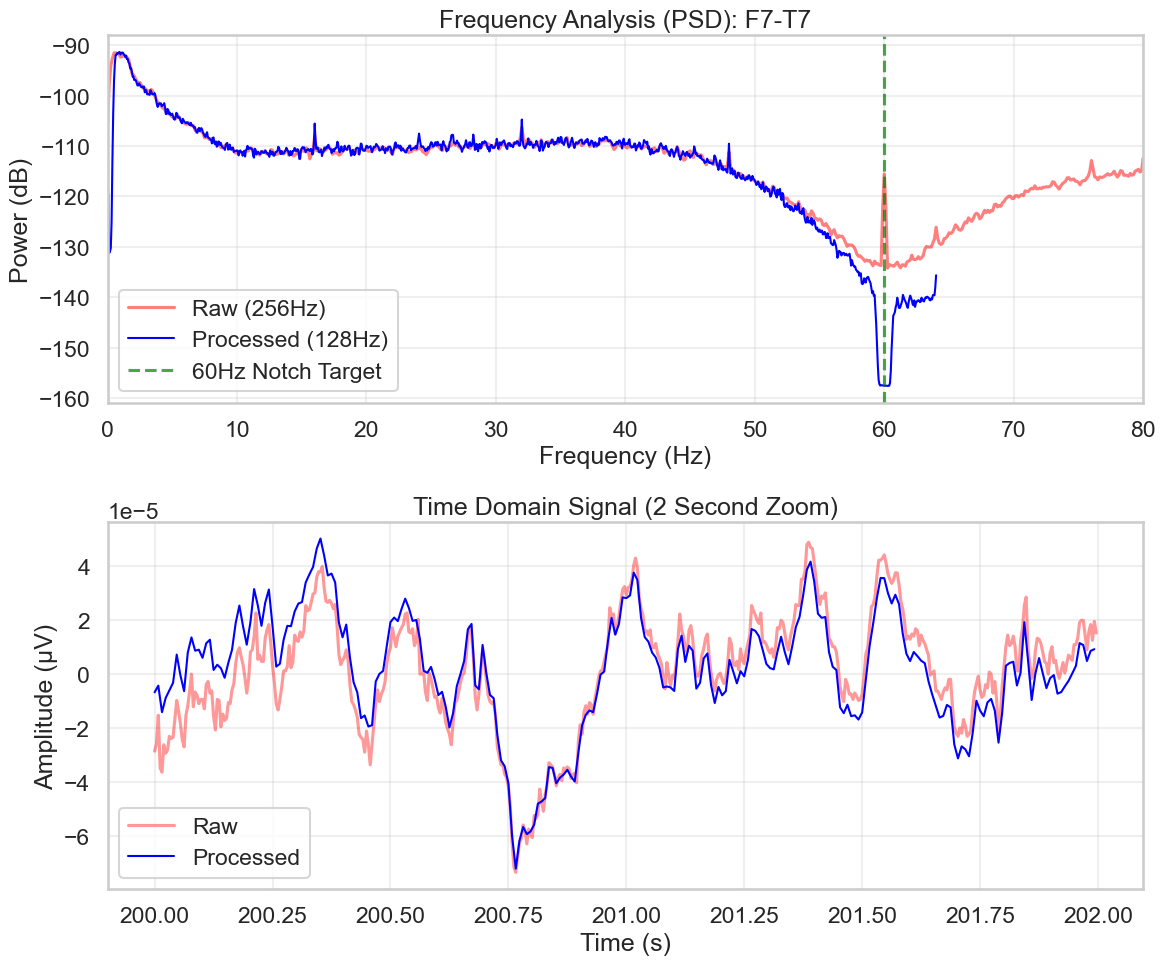

In [58]:
import matplotlib.pyplot as plt
import mne
import numpy as np

# --- 1. Settings ---
mne.set_log_level("ERROR") 

# Find a common channel
common_channels = list(set(raw_before.ch_names) & set(raw_after.ch_names))
target_channel = common_channels[0] # Usually FP1-F7 or similar

print(f"Comparing Channel: {target_channel}")

fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# --- 2. Frequency Domain (The Proof) ---
# We calculate PSD for Raw up to 100Hz to see the 60Hz noise clearly
psd_before = raw_before.compute_psd(fmax=100, picks=[target_channel])
# We calculate PSD for Processed up to 64Hz (Maximum for 128Hz sampling)
psd_after = raw_after.compute_psd(fmax=64, picks=[target_channel])

# Plot Raw in RED
ax[0].plot(psd_before.freqs, 10 * np.log10(psd_before.get_data()[0]), 
           color='red', alpha=0.5, label='Raw (256Hz)')

# Plot Processed in BLUE
ax[0].plot(psd_after.freqs, 10 * np.log10(psd_after.get_data()[0]), 
           color='blue', linewidth=1.5, label='Processed (128Hz)')

# Highlight the 60Hz Notch
ax[0].axvline(60, color='green', linestyle='--', alpha=0.7, label='60Hz Notch Target')

ax[0].set_title(f"Frequency Analysis (PSD): {target_channel}")
ax[0].set_ylabel("Power (dB)")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[0].set_xlim(0, 80) # Zoom in on the relevant area

# --- 3. Time Domain (The Signal) ---
start_sec = 200
duration = 2 # Zoom in to 2 seconds to see smoothness better

idx_b = raw_before.ch_names.index(target_channel)
idx_a = raw_after.ch_names.index(target_channel)

data_b, times_b = raw_before[idx_b, int(start_sec*256):int((start_sec+duration)*256)]
data_a, times_a = raw_after[idx_a, int(start_sec*128):int((start_sec+duration)*128)]

ax[1].plot(times_b, data_b.T, color='red', alpha=0.4, label='Raw')
ax[1].plot(times_a, data_a.T, color='blue', linewidth=1.5, label='Processed')

ax[1].set_title(f"Time Domain Signal (2 Second Zoom)")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Amplitude (µV)")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
print("Number of channels:", len(raw_after.ch_names))

Number of channels: 23


In [60]:
print("Channel order:")
for i, ch in enumerate(raw_after.ch_names):
    print(i, ch)

Channel order:
0 FP1-F7
1 F7-T7
2 T7-P7
3 P7-O1
4 FP1-F3
5 F3-C3
6 C3-P3
7 P3-O1
8 FP2-F4
9 F4-C4
10 C4-P4
11 P4-O2
12 FP2-F8
13 F8-T8
14 T8-P8-0
15 P8-O2
16 FZ-CZ
17 CZ-PZ
18 P7-T7
19 T7-FT9
20 FT9-FT10
21 FT10-T8
22 T8-P8-1


In [61]:
data = raw_after.get_data()
print("Data shape:", data.shape)

Data shape: (23, 460800)


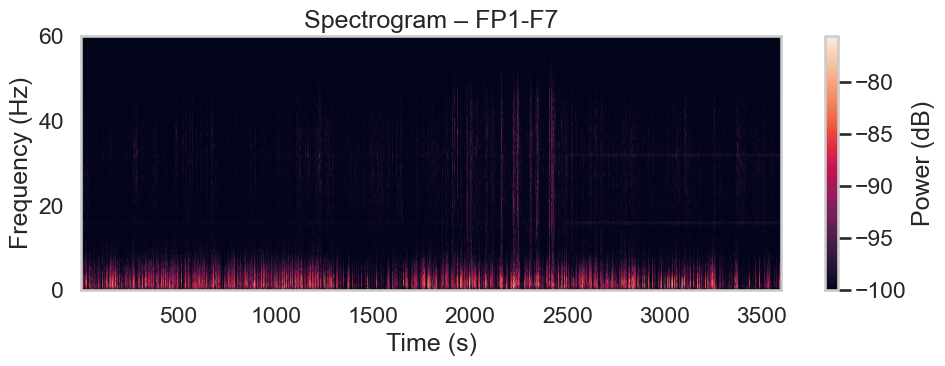

In [62]:
from scipy.signal import spectrogram
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup
ch_idx = 0  
fs = raw_after.info["sfreq"]
signal = raw_after.get_data()[ch_idx]

# 2. Compute Spectrogram
f, t, Sxx = spectrogram(signal, fs=fs, nperseg=int(fs * 2))

# 3. Plotting
plt.figure(figsize=(10, 4))

# We add 1e-10 inside log10 to prevent "RuntimeWarning: divide by zero" if Sxx has 0s
plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading="gouraud")

plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title(f"Spectrogram – {raw_after.ch_names[ch_idx]}")
plt.ylim(0, 60) # Limit y-axis to 60Hz since we filtered there
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

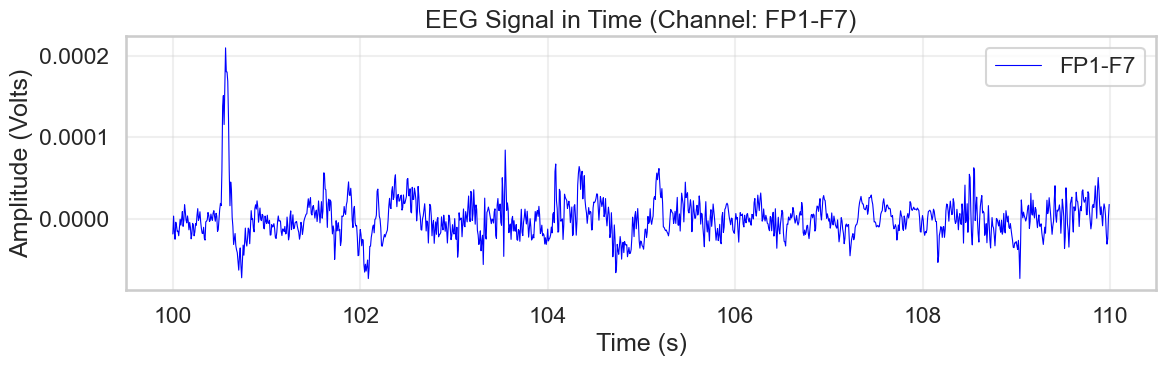

In [63]:
# 1. Setup settings
ch_idx = 0                  # Channel index to plot
start_sec = 100             # Start plotting at 100 seconds
duration_sec = 10           # Plot 10 seconds of data

# 2. Extract specific window of data
sfreq = raw_after.info['sfreq']
start_samp = int(start_sec * sfreq)
stop_samp = int((start_sec + duration_sec) * sfreq)

# raw_after[...] returns (data, times)
# data shape is (1, n_samples) because we selected one channel
data, times = raw_after[ch_idx, start_samp:stop_samp]
signal = data[0]  # Take the first (and only) channel from the array

# 3. Plot Time Domain
plt.figure(figsize=(12, 4))
plt.plot(times, signal, color='blue', lw=0.8, label=raw_after.ch_names[ch_idx])

# Styling
plt.title(f"EEG Signal in Time (Channel: {raw_after.ch_names[ch_idx]})")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (Volts)") # MNE stores data in Volts (usually µV range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

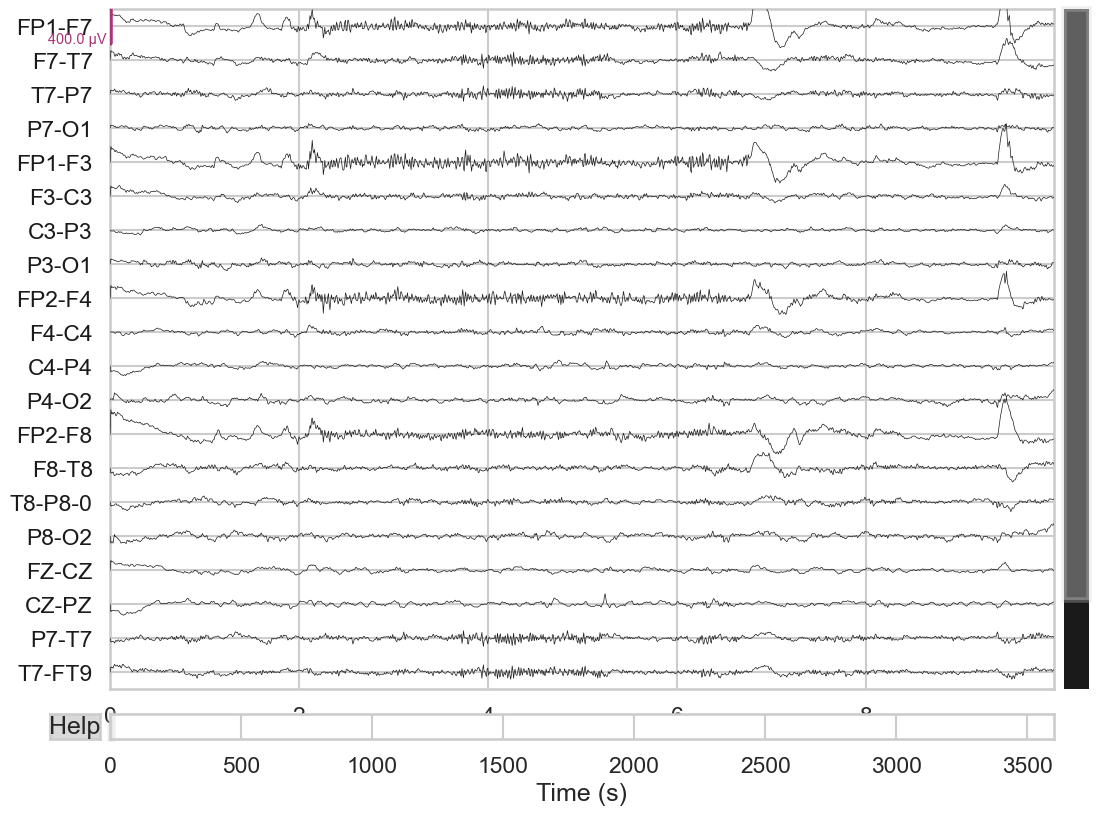

In [64]:
raw_after.plot(
    duration=10, 
    n_channels=20, 
    scalings=dict(eeg=200e-6), 
    title='Preprocessed EEG Data'
);  

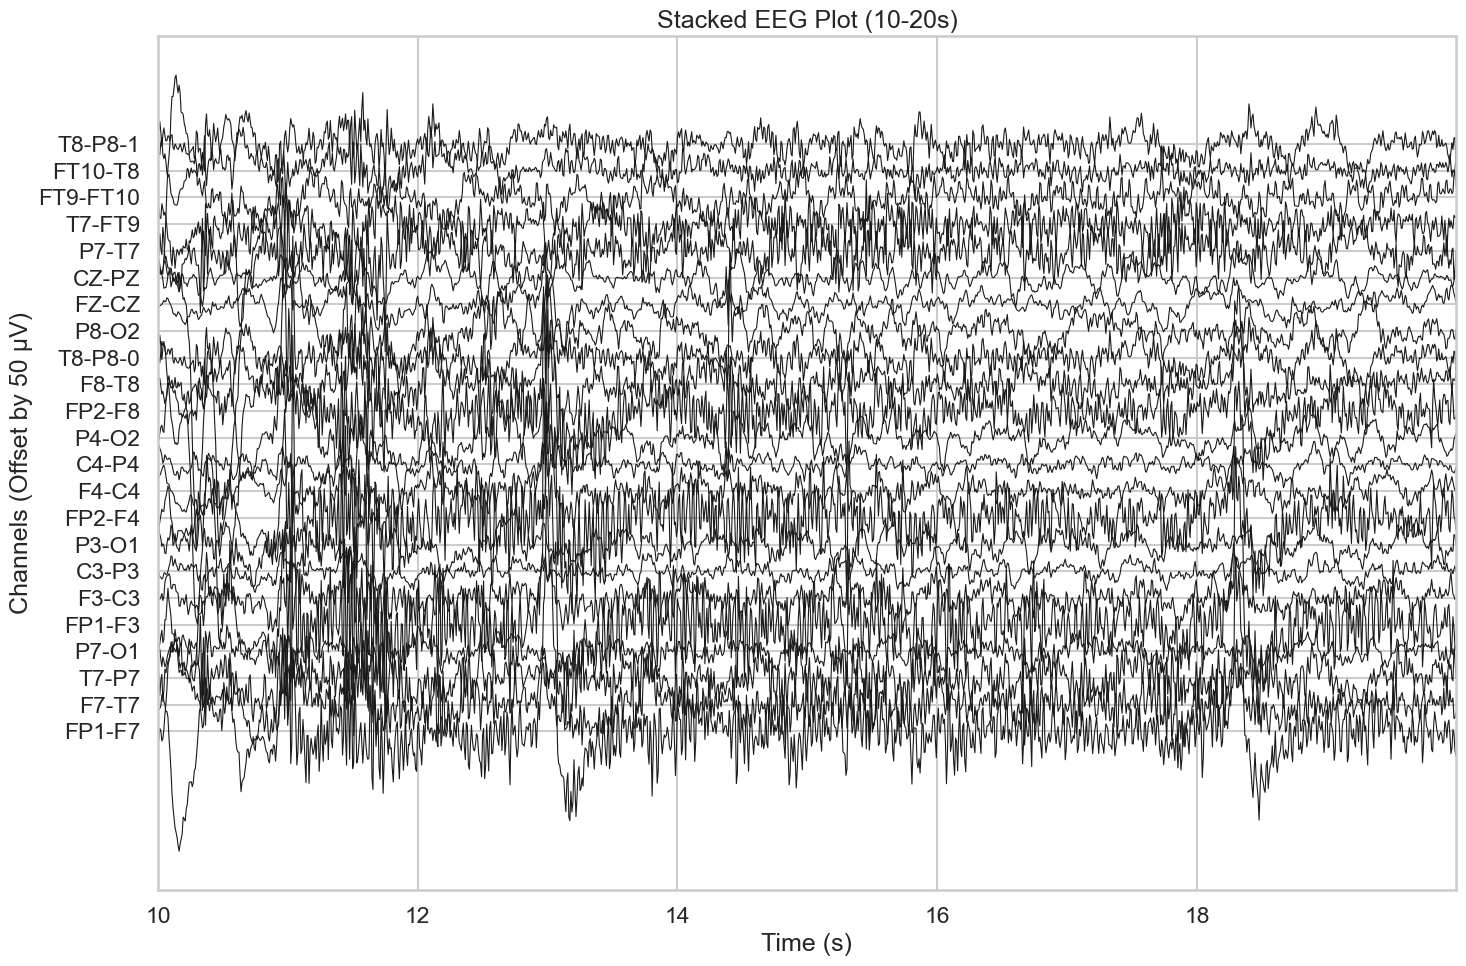

In [65]:
import matplotlib.pyplot as plt
import numpy as np

def plot_stacked_eeg(raw, start_time, duration, n_channels=10, scalings=dict):
    # 1. Select data
    sfreq = raw.info['sfreq']
    start_idx = int(start_time * sfreq)
    stop_idx = int((start_time + duration) * sfreq)
    
    # Get data and times
    data, times = raw.get_data(start=start_idx, stop=stop_idx, return_times=True)
    
    # Select subset of channels to avoid overcrowding
    ch_names = raw.ch_names[:n_channels]
    data = data[:n_channels, :]
    
    # 2. Convert to Microvolts (µV) for plotting
    data = data * 1e6 
    
    # 3. Create Offsets for Stacking
    # This separates the lines so they don't draw on top of each other
    step = 50  # Vertical distance between channels (in µV)
    offsets = np.arange(n_channels) * step
    
    # Add offsets to data
    data_shifted = data + offsets[:, np.newaxis]
    
    # 4. Plot
    fig, ax = plt.subplots(figsize=(15, 10))
    
    ax.plot(times, data_shifted.T, color='k', linewidth=0.8)
    
    # Set Y-ticks to show channel names
    ax.set_yticks(offsets)
    ax.set_yticklabels(ch_names)
    
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Channels (Offset by 50 µV)")
    ax.set_title(f"Stacked EEG Plot ({start_time}-{start_time+duration}s)")
    ax.margins(x=0)
    
    plt.tight_layout()
    plt.show()

# Usage: Plot the first 10 seconds of the first 20 channels
plot_stacked_eeg(raw_after, start_time=10, duration=10, n_channels=23, scalings=dict(eeg=200e-6))

In [66]:
# import sys
# from pathlib import Path

# # Ensure the src folder is in the python path so we can import the module
# # Assuming this script is running from the 'uvtez' root directory
# sys.path.append(str(Path.cwd() / 'src'))

# # Import your class (adjust import path based on your exact file structure)
# # If your file is at src/eeg/preprocessing.py:
# from src.eeg.preprocessing import CHBMITPreprocessor

# def run_pipeline():
#     # 1. Define Paths based on your screenshot structure
#     base_dir = Path("data/chb-mit")
#     output_dir = Path("data/preprocessed")
    
#     # Ensure directories exist
#     if not base_dir.exists():
#         print(f"Error: Data directory not found at {base_dir.resolve()}")
#         return

#     print(f"Input Directory: {base_dir}")
#     print(f"Output Directory: {output_dir}")

#     # 2. Initialize the Preprocessor
#     # We stick to defaults, which include the 2.0s window in WINDOW_LENGTHS
#     preprocessor = CHBMITPreprocessor(
#         base_dir=str(base_dir),
#         output_dir=str(output_dir),
#         subject_subset=['chb01'] # Only processing chb01 as requested
#     )

#     # 3. Run processing for Subject 01
#     print("\nStarting preprocessing for chb01...")
#     preprocessor.save_subject('chb01')
#     print("\n✅ Processing complete.")

#     # 4. Verify the 2s window data exists in the output
#     print("\n--- Verification ---")
#     subject_out_dir = output_dir / "chb01"
    
#     # Check the first generated file
#     generated_files = list(subject_out_dir.glob("*.npz"))
#     if generated_files:
#         import numpy as np
#         first_file = generated_files[0]
#         data = np.load(first_file)
        
#         if '2s' in data:
#             print(f"Successfully verified '2s' window data in {first_file.name}")
#             print(f"Shape of 2s data: {data['2s'].shape} (Windows, Channels, Samples)")
#             print(f"Shape of labels: {data['labels'].shape}")
#         else:
#             print(f"⚠️ '2s' key not found in {first_file.name}. Check WINDOW_LENGTHS in class.")
#     else:
#         print("No output files were generated.")

# if __name__ == "__main__":
#     run_pipeline()

In [67]:
# import numpy as np

# # Load a specific file
# data = np.load('data/preprocessed/chb01/chb01_01.npz')

# # Access the 2 second windows
# windows_2s = data['2s'] 
# labels = data['labels']

# print(f"Loaded {len(windows_2s)} windows of 2 seconds length.")